# Inventory Analysis Project
*This project aims to evaluate and improve the Bibitor, LLC, a retail wine and spirits company's inventory management efficiency. The primary goal is to analyze historical inventory (finish goods) data to identify metrics, optimize inventory levels, point out vendor's lead time, determine the ABC-XYZ category,  and recommend Q optimal, ROP, and Safety Stock.*

**Data source:** https://www.kaggle.com/datasets/bhanupratapbiswas/inventory-analysis-case-study

![My Image](GettyImages_142227958_optimized.jpg)

<a id="section-top"></a>
## Table of Contents

* [1. Import libraries](#section-one)

* [2. Load datasets](#section-two)

* [3. Data Wrangling](#section-three)

* [4. Sales and Profit analysis](#section-four)

* [5. Inventory Management KPIs](#section-five)
     - [5.1. Inventory Level](#section-five-one)
     - [5.2. Inventory Turnover ratio](#section-five-two)
     - [5.3. Days Inventory on Hand (DOH)](#section-five-three)
     - [5.4. Stock-to-Sales ratio (S2S)](#section-five-four)
     - [5.5. Sell-Through Rate (STR)](#section-five-five)

* [6. Brand's Lead Time analysis](#section-six)

* [7. ABC-XYZ category definition](#section-seven)
     - [7.1. ABC classification](#section-seven-one)
     - [7.2. XYZ classification](#section-seven-two)
     - [7.3. Integration of ABC and XYZ analysis](#section-seven-three)

* [8. Safety Stock and Re-order Point](#section-eight)
     - [8.1. Safety Stock with CSL (demand & lead time uncertainty)](#section-eight-one)
     - [8.2. Re-order Point (ROP)](#section-eight-two)

* [9. Fixed-Order Quantity Models (EOQ model)  ](#section-nine)

* [10. Vendors Evaluation](#section-ten)
     - [10.1. Vendor's Lead Time](#section-ten-one)
     - [10.2. Total Gross Profit per Vendor](#section-ten-two)    



<a id="section-one"></a>
## 1. Import libraries

In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy.stats as stats
import seaborn as sns

<a id="section-two"></a>
## 2. Load datasets

**Dataset Information:**

**- pur_price:** *purchase price of each brand from vendors*

**- beg_inv:** *beginning inventory of each brand at the start day of the year*

**- end_inv:** *ending inventory of each brand at the end day of the year*

**- inv_pur:** *purchase invoice of each order*

**- pur_final:** *purchase order in 2016*

**- sales_final:** *sales  in the first two months of 2016*


In [181]:
#Read datasets
pur_price = pd.read_csv("../dataset/archive/2017PurchasePricesDec.csv")
beg_inv = pd.read_csv("../dataset/archive/BegInvFINAL12312016.csv")
end_inv = pd.read_csv("../dataset/archive/EndInvFINAL12312016.csv")
inv_pur = pd.read_csv("../dataset/archive/InvoicePurchases12312016.csv")
pur_final = pd.read_csv("../dataset/archive/PurchasesFINAL12312016.csv")
sales_final = pd.read_csv("../dataset/archive/SalesFINAL12312016.csv")

#Create a dictionaries to see all dataset
data_overview = {
    "pur_price" : display(pur_price.head()),
    "beg_inv" : display(beg_inv.head()),
    "end_inv" : display(end_inv.head()),
    "inv_pur" : display(inv_pur.head()),
    "pur_final" : display(pur_final.head()),
    "sales_final" : display(sales_final.head())
}
data_overview

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2016-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2016-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2016-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2016-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2016-01-01


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2016-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2016-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2016-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2016-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2016-12-31


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2016-01-04,8124,2015-12-21,2016-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2016-01-07,8137,2015-12-22,2016-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2016-01-09,8169,2015-12-24,2016-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2016-01-12,8106,2015-12-20,2016-02-05,10100,137483.78,2935.20,NaN
4,516,BANFI PRODUCTS CORP,2016-01-07,8170,2015-12-24,2016-02-12,1935,15527.25,429.20,NaN


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2015-12-21,2016-01-02,2016-01-04,2016-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-01,2016-01-07,2016-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-02,2016-01-07,2016-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-01,2016-01-07,2016-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2015-12-24,2016-01-02,2016-01-09,2016-02-16,21.32,5,106.60,1


,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,1/1/2016,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,1/2/2016,750,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,1/3/2016,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,1/8/2016,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,1/9/2016,375,1,0.79,12546,JIM BEAM BRANDS COMPANY


{'pur_price': None,
 'beg_inv': None,
 'end_inv': None,
 'inv_pur': None,
 'pur_final': None,
 'sales_final': None}

<a id="section-three"></a>
## 3. Data Wrangling

In [182]:
#Check null values
null_check = {
    "pur_price" : display(pur_price.isna().sum()),
    "beg_inv" : display(beg_inv.isna().sum()),
    "end_inv" : display(end_inv.isna().sum()),
    "inv_pur" : display(inv_pur.isna().sum()),
    "pur_final" : display(pur_final.isna().sum()),
    "sales_final" : display(sales_final.isna().sum())
}
null_check

Brand             0
Description       1
Price             0
Size              1
Volume            1
Classification    0
PurchasePrice     0
VendorNumber      0
VendorName        0
dtype: int64

InventoryId    0
Store          0
City           0
Brand          0
Description    0
Size           0
onHand         0
Price          0
startDate      0
dtype: int64

InventoryId       0
Store             0
City           1284
Brand             0
Description       0
Size              0
onHand            0
Price             0
endDate           0
dtype: int64

VendorNumber       0
VendorName         0
InvoiceDate        0
PONumber           0
PODate             0
PayDate            0
Quantity           0
Dollars            0
Freight            0
Approval        5169
dtype: int64

InventoryId       0
Store             0
Brand             0
Description       0
Size              3
VendorNumber      0
VendorName        0
PONumber          0
PODate            0
ReceivingDate     0
InvoiceDate       0
PayDate           0
PurchasePrice     0
Quantity          0
Dollars           0
Classification    0
dtype: int64

InventoryId       0
Store             0
Brand             0
Description       0
Size              0
SalesQuantity     0
SalesDollars      0
SalesPrice        0
SalesDate         0
Volume            0
Classification    0
ExciseTax         0
VendorNo          0
VendorName        0
dtype: int64

{'pur_price': None,
 'beg_inv': None,
 'end_inv': None,
 'inv_pur': None,
 'pur_final': None,
 'sales_final': None}

In [183]:
#Drop null values
pur_price.dropna(inplace=True)
end_inv.dropna(inplace=True)
inv_pur.dropna(inplace=True)

In [184]:
#Convert data to date type
def dateformat(df, *columns):
    for col in columns:
        df[col] = pd.to_datetime(df[col])
    return df

pur_final = dateformat(pur_final, 'ReceivingDate','PODate')
sales_final = dateformat(sales_final, 'SalesDate')
beg_inv = dateformat(beg_inv, 'startDate')

<a id="section-four"></a>
## 4. Sales and Profit Analysis

2016-01-01 00:00:00
2016-02-29 00:00:00
59 days


<Axes: title={'center': 'Daily Sales Trendss'}, xlabel='SalesDate'>

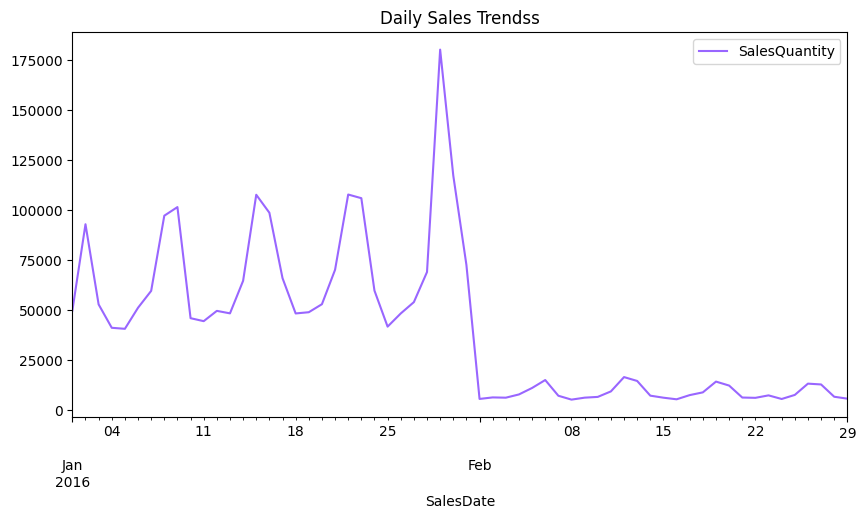

In [185]:
#Time window of sales data
print(sales_final['SalesDate'].min())
print(sales_final['SalesDate'].max())
print((sales_final['SalesDate'].max()-sales_final['SalesDate'].min()).days, 'days')

#Number of total quantity sold per day
total_quantity_per_day = sales_final[['SalesDate', 'SalesQuantity']].groupby('SalesDate', as_index= False).sum()
total_quantity_per_day.plot(kind= 'line', x='SalesDate', y= 'SalesQuantity', title= 'Daily Sales Trendss', figsize=(10,5), color= '#9966FF')

C:\Users\Zenbook\AppData\Local\Temp\ipykernel_13044\2805041821.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(total_quantity_per_brand['Description'],    rotation=45, ha='right')


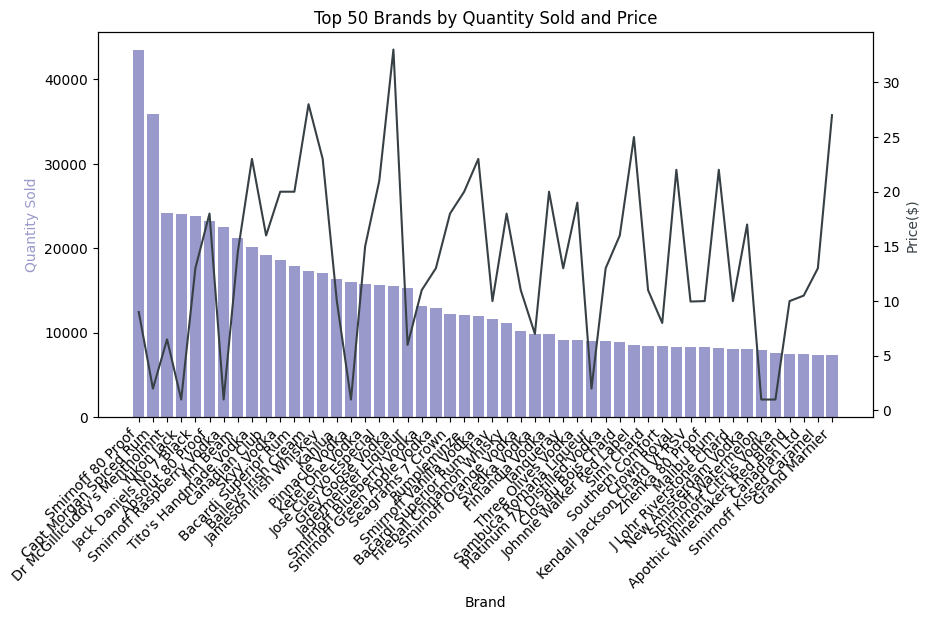

In [186]:
total_quantity_per_brand = sales_final[[ 'Description', 'SalesPrice', 'SalesQuantity']].groupby(['Description'], as_index= False).agg({'SalesPrice':'first',
                                                                                                                                       'SalesQuantity':'sum'}).sort_values('SalesQuantity', ascending= False)
 
fig, ax1 = plt.subplots(figsize=(10, 5))

ax2 = ax1.twinx()
ax1.bar(total_quantity_per_brand['Description'].head(50), total_quantity_per_brand['SalesQuantity'].head(50), color='#9999CC')
ax2.plot(total_quantity_per_brand['Description'].head(50), total_quantity_per_brand['SalesPrice'].head(50), '#374045')

ax1.set_xlabel('Brand')
ax1.set_ylabel('Quantity Sold', color='#9999CC')
ax2.set_ylabel('Price($)', color='#374045')
ax1.set_xticklabels(total_quantity_per_brand['Description'],    rotation=45, ha='right')
plt.title('Top 50 Brands by Quantity Sold and Price')

plt.show()

In [187]:
#Create a total stock dataframe in 2016
stock_df1= beg_inv[['Brand', 'Description','onHand','Price']].copy()
stock_df1.rename(columns={'onHand':'Quantity'}, inplace= True)
stock_df1= stock_df1.groupby(['Brand', 'Description','Price'], as_index=False).sum()

purchases_with_prices = pd.merge(pur_final,pur_price[['Brand', 'Description','Price']],on=['Brand', 'Description'],how='left')

stock_df2 = purchases_with_prices[['Brand', 'Description','Quantity','Price']]
stock_df2 = stock_df2.groupby(['Brand', 'Description','Price'], as_index=False).sum()

stock_df3 = pd.concat([stock_df1, stock_df2]).reset_index(drop=True)

stock_df3.head()

,Brand,Description,Price,Quantity
0,58,Gekkeikan Black & Gold Sake,12.99,281
1,60,Canadian Club 1858 VAP,10.99,288
2,61,Margaritaville Silver,13.99,12
3,62,Herradura Silver Tequila,36.99,384
4,63,Herradura Reposado Tequila,38.99,365


In [188]:
#Calculate total SalesQuantity and total SalesDollars of each brand in the first two months 
sales_total = sales_final[['Brand', 'Description', 'SalesQuantity', 'SalesDollars', 'SalesPrice']].groupby(['Brand', 'Description', 'SalesPrice']).sum().reset_index()
sales_total.head()

,Brand,Description,SalesPrice,SalesQuantity,SalesDollars
0,58,Gekkeikan Black & Gold Sake,12.99,288,3741.12
1,60,Canadian Club 1858 VAP,9.99,4,39.96
2,60,Canadian Club 1858 VAP,10.99,120,1318.80
3,61,Margaritaville Silver,13.99,24,335.76
4,62,Herradura Silver Tequila,36.99,50,1849.50


In [189]:
#Calculate COGS value of each brand
COGS_df = pd.merge(sales_total[['Brand', 'Description', 'SalesPrice', 'SalesQuantity']], pur_price[['Brand', 'Description', 'PurchasePrice']], how='left', on= ['Brand','Description'] )
COGS_df['COGS'] = COGS_df['SalesQuantity']*COGS_df['PurchasePrice']
COGS_df['Profit'] = COGS_df['SalesQuantity']*(COGS_df['SalesPrice'] - COGS_df['PurchasePrice'])
COGS_df.head()

,Brand,Description,SalesPrice,SalesQuantity,PurchasePrice,COGS,Profit
0,58,Gekkeikan Black & Gold Sake,12.99,288,9.28,2672.64,1068.48
1,60,Canadian Club 1858 VAP,9.99,4,7.40,29.60,10.36
2,60,Canadian Club 1858 VAP,10.99,120,7.40,888.00,430.80
3,61,Margaritaville Silver,13.99,24,10.60,254.40,81.36
4,62,Herradura Silver Tequila,36.99,50,28.67,1433.50,416.00


In [190]:
#Result getting:
print('Number of brands in 2016:',  stock_df3['Brand'].nunique(),'brands')
print('Number of brands was sold in the first two month of 2016:',  sales_final['Brand'].nunique(),'brands')
print('Total items was sold in the first two month of 2016:',  COGS_df['SalesQuantity'].sum(),'items')
print('Total COGS value was generated:', COGS_df['COGS'].sum().round(2),'dollars')
print('Total revenue generated:', sales_total['SalesDollars'].sum() ,'dollars')
print('Total gross profit:', (COGS_df['Profit'].sum()).round(2) ,'dollars')
print('Return on Sales (ROS):', (COGS_df['Profit'].sum()/sales_total['SalesDollars'].sum()).round(2))
print('Item sold price between', sales_final['SalesPrice'].min(),'and', sales_final['SalesPrice'].max(), 'dollars')

Number of brands in 2016: 11485 brands
Number of brands was sold in the first two month of 2016: 7658 brands
Total items was sold in the first two month of 2016: 2451169 items
Total COGS value was generated: 22299640.77 dollars
Total revenue generated: 33139375.29 dollars
Total gross profit: 10839734.52 dollars
Return on Sales (ROS): 0.33
Item sold price between 0.49 and 4999.99 dollars


<a id="section-five"></a>
## 5. Inventory Management KPIs

<a id="section-five-one"></a>
### 5.1. Inventory Level

**Create data frames for the next step:**

*- Firstly, create a data frame (turn df3) that includes data on the quantity of the receiving or the sales transactions during the time window (the first two months of 2016).*

In [191]:
turn_df1 = (sales_final[['Brand', 'Description', 'SalesDate', 'SalesQuantity']].rename(columns= {'SalesDate':'TransactionDate'})
            ).groupby(['Brand', 'Description', 'TransactionDate'], as_index=False).sum()

turn_df2 = ((pur_final[['Brand', 'Description', 'ReceivingDate', 'Quantity']].loc[pur_final['ReceivingDate'] <= sales_final['SalesDate'].max()]).rename(columns= {'ReceivingDate':'TransactionDate',
                                                                                                                                                                 'Quantity': 'PurchasedQuantity'})
            ).groupby(['Brand', 'Description', 'TransactionDate'], as_index=False).sum()

turn_df3 = pd.merge(turn_df1, turn_df2, 
                    how= 'outer', #retain all rows
                    on= ['Brand', 'Description', 'TransactionDate'])
turn_df3.fillna(0, inplace=True) #the day does not have any receiving or sales transactions will be replace with zero
turn_df3.head()

,Brand,Description,TransactionDate,SalesQuantity,PurchasedQuantity
0,58,Gekkeikan Black & Gold Sake,2016-01-01,7.0,6.0
1,58,Gekkeikan Black & Gold Sake,2016-01-02,13.0,5.0
2,58,Gekkeikan Black & Gold Sake,2016-01-03,7.0,0.0
3,58,Gekkeikan Black & Gold Sake,2016-01-04,3.0,0.0
4,58,Gekkeikan Black & Gold Sake,2016-01-05,5.0,0.0


*Secondly, create a data frame (turn_df4) containing the beginning inventory quantity ​​of each brand and merge it with the previous data frame (turn_df3) to get the new data frame (turn_df5) that has both the sales, purchased, and beginning data.*

In [192]:
turn_df4 = (beg_inv[['Brand', 'Description', 'startDate', 'onHand']].rename(columns= {'onHand': 'BeginningInventory',
                                                                                      'startDate':'TransactionDate'})
            ).groupby(['Brand', 'Description', 'TransactionDate'], as_index= False)['BeginningInventory'].sum()

turn_df5 = pd.merge(turn_df3, turn_df4, 
                    on=['Brand', 'Description', 'TransactionDate'], 
                    how='outer')
turn_df5.head()

,Brand,Description,TransactionDate,SalesQuantity,PurchasedQuantity,BeginningInventory
0,58,Gekkeikan Black & Gold Sake,2016-01-01,7.0,6.0,281.0
1,58,Gekkeikan Black & Gold Sake,2016-01-02,13.0,5.0,NaN
2,58,Gekkeikan Black & Gold Sake,2016-01-03,7.0,0.0,NaN
3,58,Gekkeikan Black & Gold Sake,2016-01-04,3.0,0.0,NaN
4,58,Gekkeikan Black & Gold Sake,2016-01-05,5.0,0.0,NaN


*Finally, only keeps brands whose begginning inventory quantity has been recorded.*

In [193]:
turn_df6 = pd.merge(turn_df5, turn_df4[['Brand', 'Description']], 
                    on= ['Brand', 'Description'],
                    how= 'right')
turn_df6.fillna(0, inplace=True)
turn_df6.head()

,Brand,Description,TransactionDate,SalesQuantity,PurchasedQuantity,BeginningInventory
0,58,Gekkeikan Black & Gold Sake,2016-01-01,7.0,6.0,281.0
1,58,Gekkeikan Black & Gold Sake,2016-01-02,13.0,5.0,0.0
2,58,Gekkeikan Black & Gold Sake,2016-01-03,7.0,0.0,0.0
3,58,Gekkeikan Black & Gold Sake,2016-01-04,3.0,0.0,0.0
4,58,Gekkeikan Black & Gold Sake,2016-01-05,5.0,0.0,0.0


**Calculate the inventory level following this formulas:**

*- Ending Inventory = Beginning Inventory + Purchased Quantity - Sales Quantity*

*(The ending inventory of the previous day will become the beginning inventory of the next day)*

In [194]:
#Calculate inventory level 
turn_df6['InventoryLevel'] = 0.0

df_list = []

for product in turn_df6['Brand'].unique():
    
    turn_df7 = turn_df6[turn_df6['Brand'] == product].reset_index(drop= True)
    
    turn_df7.at[0, 'InventoryLevel'] = turn_df7.at[0, 'BeginningInventory']
    
    """ Ending Inventory = Beginning Inventory + Purchase Quantity - Sales Quantity"""
    
    for i in range(1, len(turn_df7)):
        turn_df7.at[i, 'InventoryLevel'] = turn_df7.at[i-1, 'InventoryLevel'] + turn_df7.at[i-1, 'PurchasedQuantity'] - turn_df7.at[i-1, 'SalesQuantity']
        
    df_list.append(turn_df7)
    
turn_df6 = pd.concat(df_list).reset_index(drop=True)

turn_df6.head()

,Brand,Description,TransactionDate,SalesQuantity,PurchasedQuantity,BeginningInventory,InventoryLevel
0,58,Gekkeikan Black & Gold Sake,2016-01-01,7.0,6.0,281.0,281.0
1,58,Gekkeikan Black & Gold Sake,2016-01-02,13.0,5.0,0.0,280.0
2,58,Gekkeikan Black & Gold Sake,2016-01-03,7.0,0.0,0.0,272.0
3,58,Gekkeikan Black & Gold Sake,2016-01-04,3.0,0.0,0.0,265.0
4,58,Gekkeikan Black & Gold Sake,2016-01-05,5.0,0.0,0.0,262.0


<a id="section-five-two"></a>
### 5.2. Inventory Turnover ratio

**Inventory turnover ratio** *is a financial ratio showing how many times a company turned over its inventory in a given period.*

**Formula:**

*- Inventory Turnover = Cost of Gold Sold/Average Inventory Value = Demand/Average Inventory Level*


In [195]:
#Calculate average inventory level
turn_df6 = turn_df6[['Brand', 'Description','TransactionDate', 'InventoryLevel']].pivot(index=['Brand', 'Description'],
                                                                                        columns='TransactionDate', 
                                                                                        values='InventoryLevel',)
turn_df6 = turn_df6.fillna(method= 'ffill', axis=1)
turn_df6['AverageInventoryLevel'] = ((turn_df6.mean(axis=1)).astype(float)).round(2)
turn_df6.reset_index(inplace= True)
turn_df6.head()

C:\Users\Zenbook\AppData\Local\Temp\ipykernel_13044\1361280654.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  turn_df6 = turn_df6.fillna(method= 'ffill', axis=1)


TransactionDate,Brand,Description,2016-01-01 00:00:00,2016-01-02 00:00:00,2016-01-03 00:00:00,2016-01-04 00:00:00,2016-01-05 00:00:00,2016-01-06 00:00:00,2016-01-07 00:00:00,2016-01-08 00:00:00,...,2016-02-21 00:00:00,2016-02-22 00:00:00,2016-02-23 00:00:00,2016-02-24 00:00:00,2016-02-25 00:00:00,2016-02-26 00:00:00,2016-02-27 00:00:00,2016-02-28 00:00:00,2016-02-29 00:00:00,AverageInventoryLevel
0,58,Gekkeikan Black & Gold Sake,281.0,280.0,272.0,265.0,262.0,257.0,253.0,247.0,...,468.0,464.0,469.0,495.0,519.0,525.0,534.0,532.0,530.0,353.02
1,60,Canadian Club 1858 VAP,288.0,285.0,276.0,271.0,268.0,267.0,264.0,261.0,...,167.0,167.0,167.0,167.0,167.0,167.0,167.0,167.0,167.0,200.75
2,61,Margaritaville Silver,12.0,12.0,12.0,12.0,12.0,12.0,12.0,0.0,...,24.0,24.0,24.0,36.0,36.0,36.0,36.0,36.0,36.0,17.80
3,62,Herradura Silver Tequila,384.0,387.0,390.0,384.0,402.0,435.0,445.0,444.0,...,548.0,545.0,571.0,582.0,591.0,603.0,603.0,609.0,607.0,471.40
4,63,Herradura Reposado Tequila,365.0,363.0,355.0,354.0,360.0,386.0,405.0,407.0,...,504.0,504.0,503.0,503.0,514.0,527.0,536.0,536.0,539.0,431.00


In [196]:
#Calculate total sales of each brand
total = sales_total[['Brand', 'Description', 'SalesQuantity']].groupby(['Brand', 'Description'], as_index= False).sum()

#Inventory Turnover 
turn_df7 = pd.merge(turn_df6[['Brand', 'Description', 'AverageInventoryLevel']].loc[turn_df6['AverageInventoryLevel'] != 0], total, 
                    how= 'inner', 
                    on= ['Brand', 'Description'])

turn_df7['InventoryTurnover'] = (turn_df7['SalesQuantity']/turn_df7['AverageInventoryLevel']).round(2)

turn_df7.head()

,Brand,Description,AverageInventoryLevel,SalesQuantity,InventoryTurnover
0,58,Gekkeikan Black & Gold Sake,353.02,288,0.82
1,60,Canadian Club 1858 VAP,200.75,124,0.62
2,61,Margaritaville Silver,17.80,24,1.35
3,62,Herradura Silver Tequila,471.40,162,0.34
4,63,Herradura Reposado Tequila,431.00,131,0.30


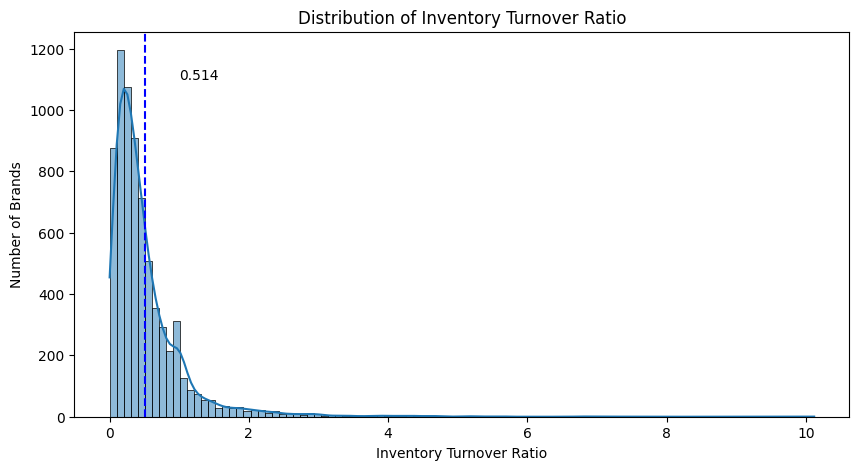

In [197]:
#Distribution of Inventory Turnover Ratio
fig, ax = plt.subplots(figsize = (10,5))
sns.histplot(turn_df7['InventoryTurnover'], kde= True, bins= 100)
avg_line = turn_df7['InventoryTurnover'].mean()

plt.title('Distribution of Inventory Turnover Ratio')
plt.xlabel('Inventory Turnover Ratio')
plt.ylabel('Number of Brands')

plt.axvline(avg_line, color = 'blue', linestyle = '--', linewidth = 1.5)

plt.text(1, 1100, avg_line.round(3))

plt.show()

In [198]:
#Top 10 brands with the highest Inventory Turnover:
top10_turn = turn_df7[['Brand', 'Description', 'InventoryTurnover']].sort_values(by='InventoryTurnover', ascending= False).reset_index(drop= True)
print('Top 10 brands with the highest Inventory Turnover: \n', top10_turn.head(10))

Top 10 brands with the highest Inventory Turnover: 
    Brand                   Description  InventoryTurnover
0  19867  Tierra de Antes Malbec Mndza              10.12
1  20550  Fifty Shades Of Grey Red Sat               7.52
2  18017         Verde Sole Pnt Grigio               7.22
3  20626   Les Dauphins Cotes du Rhone               6.86
4  21884            St Julien Rose CDR               6.76
5   6764     El Jimador Silver Tequila               5.62
6   6257       Carlo Rossi Blush Calif               5.61
7  44338              Irony Chard Napa               5.45
8  20184       Charles & Charles Chard               5.22
9  38103      Canyon Oaks Cab Svgn Cal               5.22


### 5.3. Days Inventory on Hand (DOH)

**Days of Inventory on Hand (DOH)** *is a metric used to determine how quickly a company utilizes the average inventory available at its disposal. It is also known as days inventory outstanding (DIO).*

**Formula:**

*- Day of Inventory on Hand (DOH) = (Average Inventory Value/Cost of Gold Sold) x 365 = (1/Inventory Turnover) x 365*

*Reference: https://www.linkedin.com/pulse/inventory-days-hand-turns-simplified-chris-agner-cpim-cscp-ssgb/*


In [199]:
time_in_day = (sales_final['SalesDate'].max() - sales_final['SalesDate'].min()).days
print('Number of days operating:', time_in_day, 'days')

Number of days operating: 59 days


In [200]:
turn_df7['DOH'] = (((1/turn_df7['InventoryTurnover'])*time_in_day).astype(float)).round(2)
turn_df7.head()

,Brand,Description,AverageInventoryLevel,SalesQuantity,InventoryTurnover,DOH
0,58,Gekkeikan Black & Gold Sake,353.02,288,0.82,71.95
1,60,Canadian Club 1858 VAP,200.75,124,0.62,95.16
2,61,Margaritaville Silver,17.80,24,1.35,43.70
3,62,Herradura Silver Tequila,471.40,162,0.34,173.53
4,63,Herradura Reposado Tequila,431.00,131,0.30,196.67


In [201]:
#Top 10 brands with the shortest DOH:
top10_DOH = turn_df7[['Brand', 'Description', 'DOH']].sort_values(by='DOH', ascending= True)
print('Top 10 brands with the shortest Days of inventory on hand(DOH): \n', top10_DOH.head(10))

Top 10 brands with the shortest Days of inventory on hand(DOH): 
       Brand                   Description    DOH
4263  19867  Tierra de Antes Malbec Mndza   5.83
4403  20550  Fifty Shades Of Grey Red Sat   7.85
3832  18017         Verde Sole Pnt Grigio   8.17
4413  20626   Les Dauphins Cotes du Rhone   8.60
4728  21884            St Julien Rose CDR   8.73
2263   6764     El Jimador Silver Tequila  10.50
2124   6257       Carlo Rossi Blush Calif  10.52
6938  44338              Irony Chard Napa  10.83
4328  20184       Charles & Charles Chard  11.30
6467  38103      Canyon Oaks Cab Svgn Cal  11.30


<a id="section-five-four"></a>
### 5.4. Stock-to-Sales ratio (S2S)

**Stock to sales ratio,** *also known as inventory to sales ratio or I/S ratio, measures the value of your inventory against the value of sales for a certain period of time.*

**Formula:**

*- Stock-to-Sales (S2S) = Average Inventory Value/Net Sales Value*

In [202]:
S2S_df1 = sales_total[['Brand', 'Description', 'SalesDollars']].groupby(['Brand', 'Description']).sum()

S2S_df2 = pd.merge(turn_df7[['Brand', 'Description', 'AverageInventoryLevel']], pur_price[['Brand', 'Description', 'Price']], 
                   how= 'left',
                   on= ['Brand', 'Description'])

S2S_df2['AverageInventoryValue'] = S2S_df2['Price']*S2S_df2['AverageInventoryLevel']

S2S_df3 = pd.merge(S2S_df1, S2S_df2, 
                   how= 'right',
                   on= ['Brand', 'Description'])

S2S_df3['StocktoSales'] = ((S2S_df3['AverageInventoryValue']/S2S_df3['SalesDollars']).astype(float)).round(2)

S2S_df3.head()

,Brand,Description,SalesDollars,AverageInventoryLevel,Price,AverageInventoryValue,StocktoSales
0,58,Gekkeikan Black & Gold Sake,3741.12,353.02,12.99,4585.7298,1.23
1,60,Canadian Club 1858 VAP,1358.76,200.75,10.99,2206.2425,1.62
2,61,Margaritaville Silver,335.76,17.80,13.99,249.0220,0.74
3,62,Herradura Silver Tequila,6552.38,471.40,36.99,17437.0860,2.66
4,63,Herradura Reposado Tequila,5552.69,431.00,38.99,16804.6900,3.03


In [203]:
#Top 10 brands with the smallest S2S:
top10_S2S = S2S_df3[['Brand', 'Description', 'StocktoSales']].sort_values(by='StocktoSales', ascending= True)
print('Top 10 brands with the smallest S2S: \n', top10_S2S.head(10))

Top 10 brands with the smallest S2S: 
       Brand                   Description  StocktoSales
4403  20550  Fifty Shades Of Grey Red Sat          0.13
3832  18017         Verde Sole Pnt Grigio          0.14
2124   6257       Carlo Rossi Blush Calif          0.18
379    1059         Old St Nick's Egg Nog          0.19
6467  38103      Canyon Oaks Cab Svgn Cal          0.19
2186   6472  Richards Wild Irish Rose Red          0.19
2263   6764     El Jimador Silver Tequila          0.20
4477  20947              Catalpa Cab Svgn          0.21
2992  12378  Pacific Rim Organic Riesling          0.21
7099  46371  Carlo Rossi RSV Cab Svgn Cal          0.21


<a id="section-five-five"></a>
### 5.5. Sell-Through Rate (STR)

*The* **Sell-Through Rate (STR)** *is a key performance indicator (KPI) used in retail and inventory management to measure the efficiency at which inventory is sold within a specific period, typically a month or a season.*

**Formula:**

*- Sell-Through Rate(%) = (Number of Units Sold / Number of Units Received) × 100*

In [204]:
STR_df = pd.merge(turn_df3[['Brand', 'Description', 'SalesQuantity', 'PurchasedQuantity']].groupby(['Brand', 'Description'], as_index= False).sum(), turn_df4.drop(columns= 'TransactionDate'), 
                  on= ['Brand', 'Description'],
                  how= 'inner')

STR_df['SellThroughRate'] = round((STR_df['SalesQuantity']/(STR_df['PurchasedQuantity']+STR_df['BeginningInventory']))*100, 2)

STR_df.head()

,Brand,Description,SalesQuantity,PurchasedQuantity,BeginningInventory,SellThroughRate
0,58,Gekkeikan Black & Gold Sake,288.0,543.0,281,34.95
1,60,Canadian Club 1858 VAP,124.0,11.0,288,41.47
2,61,Margaritaville Silver,24.0,60.0,12,33.33
3,62,Herradura Silver Tequila,162.0,397.0,384,20.74
4,63,Herradura Reposado Tequila,131.0,314.0,365,19.29


In [205]:
#A number of brands that sold all of each item during the time window (100% STR):
count_100 = STR_df[STR_df['SellThroughRate'] == STR_df['SellThroughRate'].max()]['SellThroughRate'].count()
percentage_100 = round((count_100/STR_df.shape[0])*100, 2)

print('A number of brands that sold all of each item during the time window (100% STR):', count_100, 'brands', percentage_100, '%')

A number of brands that sold all of each item during the time window (100% STR): 282 brands 3.86 %


<a id="section-six"></a>
## 6. Brand's Lead Time analysis


![My Image](https://cdn.corporatefinanceinstitute.com/assets/Lead-Time-Diagram-.png)

*Calculate the brand lead time following the difference between* **ReceivingDate** *and* **PODate**

In [206]:
#Calculate Leadtime
pur_final['Leadtime'] = (pur_final['ReceivingDate'] - pur_final['PODate']).dt.days
pur_final.head()

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification,Leadtime
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2015-12-21,2016-01-02,2016-01-04,2016-02-16,35.71,6,214.26,1,12
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-01,2016-01-07,2016-02-21,9.35,4,37.40,1,10
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-02,2016-01-07,2016-02-21,9.41,5,47.05,1,11
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-01,2016-01-07,2016-02-21,9.35,6,56.10,1,10
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2015-12-24,2016-01-02,2016-01-09,2016-02-16,21.32,5,106.60,1,9


In [207]:
#Average leadtime of each brand
brand_lt = pur_final[['Brand','Description','Leadtime']].groupby(['Brand','Description'], as_index=False).agg(Min_LT = ('Leadtime', 'min'),
                                                                                                              Max_LT = ('Leadtime', 'max'),
                                                                                                              Avg_LT= ('Leadtime', 'mean'),
                                                                                                              Std_LT = ('Leadtime', 'std')
                                                                                                              ).round(2).sort_values(by = ['Avg_LT'], ascending =True).reset_index(drop=True)

brand_lt.head()

,Brand,Description,Min_LT,Max_LT,Avg_LT,Std_LT
0,24287,Bollini RSV Pinot Grigio,3,3,3.0,0.0
1,19255,Yosemite Road Red,3,3,3.0,NaN
2,5837,Leroux Cherry Brandy,3,3,3.0,NaN
3,26020,Hirsch Gruner Veltliner,3,3,3.0,0.0
4,20776,JM Gobillard Tradition Brut,3,3,3.0,NaN


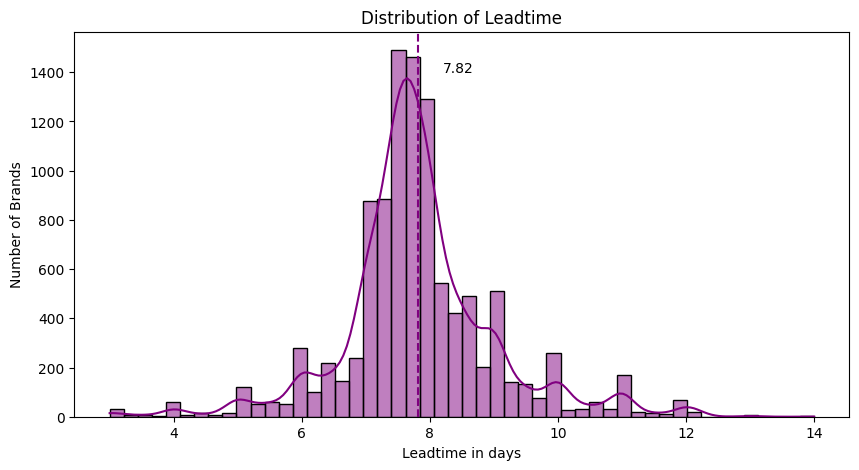

In [208]:
#Distribution of brand's leadtime
fig, ax = plt.subplots(figsize = (10,5))
sns.histplot(brand_lt['Avg_LT'], kde= True, bins= 50, color= 'purple')
avg_line = brand_lt['Avg_LT'].mean()

plt.title('Distribution of Leadtime')
plt.xlabel('Leadtime in days')
plt.ylabel('Number of Brands')

plt.axvline(avg_line, color = 'purple', linestyle = '--', linewidth = 1.5)

plt.text(8.2, 1400, avg_line.round(2))

plt.show()

In [209]:
#Define top risk of stockout based on Leadtime and Inventory Level
risk_df = pd.merge(brand_lt[['Brand', 'Description', 'Avg_LT']], turn_df6[['Brand', 'Description','AverageInventoryLevel']], how= 'inner', on= ['Brand', 'Description'])

risk_df['RiskScore'] = (risk_df['Avg_LT'] * (1-risk_df['AverageInventoryLevel'])).round(2)

top10_risk = risk_df[['Brand', 'Description', 'RiskScore']].sort_values(by='RiskScore', ascending= False).reset_index(drop= True)

print('Top 10 brands with the highest risk of stockout: \n', top10_risk.head(10))

Top 10 brands with the highest risk of stockout: 
    Brand                   Description  RiskScore
0  15901    Merry Edwards Georg Pnt Nr      10.70
1  21102       Taylor New York Marsala       8.60
2  17909      Ravenswood Pickberry Red       8.21
3  21856     Waterstone Chard Carneros       8.00
4  25429  Ch Pesquie Quint Ventoux Red       8.00
5  22647  Guillaume Vrignaud Chablis 1       8.00
6  43542  Carlo Rossi RSV Cab Svgn Cal       7.88
7  42676  Kistler Chard Sonma Mountain       7.71
8  19454  J Vineyards Vin Gris Rose RR       7.56
9   8581              Stagg Jr Bourbon       7.36


<a id="section-seven"></a>
## 7. ABC-XYZ category definition

*It is a combination of ABC(by Cumulative Percentage of Revenue) and XYZ(by Coefficient of Variation) analysis methods*

<a id="section-seven-one"></a>
### 7.1. ABC classification

*For* **ABC analysis,** *the Pareto principle states that for many outcomes, roughly 80% of consequences come from 20% of causes.*

![My Image](https://public-images.interaction-design.org/tags/td-pareto-principle-diagram.png)

In [210]:
#Create the ABC_df data frame by using relative data frame sales_total
ABC_df = (sales_total[['Brand', 'Description', 'SalesQuantity', 'SalesDollars']].rename(columns={'SalesDollars':'RevenueGenerated'})).groupby(['Brand', 'Description'], as_index= False).sum()
ABC_df.head()

,Brand,Description,SalesQuantity,RevenueGenerated
0,58,Gekkeikan Black & Gold Sake,288,3741.12
1,60,Canadian Club 1858 VAP,124,1358.76
2,61,Margaritaville Silver,24,335.76
3,62,Herradura Silver Tequila,162,6552.38
4,63,Herradura Reposado Tequila,131,5552.69


In [211]:
#Create function
def ABC_segmentation(perc):
    if perc > 0 and perc < 0.8:
        return 'A'
    elif perc >= 0.8 and perc < 0.95:
        return 'B'
    elif perc >= 0.95:
        return 'C'

In [212]:
def ABC_classifier(df, revenue):
    #Order by revenue
    data_seg = df.sort_values(by = [revenue], ascending =False).reset_index()
    #Create the column of the total sum revenue
    data_seg['TotalRev'] = data_seg[revenue].sum()
    #Create the column of percentage of Revenue per Brand
    data_seg['%Rev'] = 100*(data_seg[revenue]/data_seg['TotalRev'])
    #Create the column of the cumulative revenue per Brand
    data_seg['CumRev'] = data_seg[revenue].cumsum()
    #Create the column of the running percentage of CumRev
    data_seg['PerCumTot'] = data_seg['CumRev']/data_seg['TotalRev']
    # Create the column of the class by apply ABC_segmentation
    data_seg['Class'] = data_seg['PerCumTot'].apply(ABC_segmentation)
    #Create SKU_ID column
    data_seg['SKU_ID'] = pd.Series(range(1, len(data_seg['PerCumTot']) + 1)).astype(int)
    #Cumulative Percent of SKU
    data_seg['SKU_%'] = (100 * pd.Series(range(1, len(data_seg['PerCumTot']) + 1)) / (len(data_seg['PerCumTot']) + 1))
    #Drop index column
    data_seg.drop(columns='index', inplace=True)

    return data_seg

In [213]:
data_seg = ABC_classifier(ABC_df, 'RevenueGenerated')
data_seg.head()

,Brand,Description,SalesQuantity,RevenueGenerated,TotalRev,%Rev,CumRev,PerCumTot,Class,SKU_ID,SKU_%
0,4261,Capt Morgan Spiced Rum,20226,444810.74,33139375.29,1.342242,444810.74,0.013422,A,1,0.013057
1,3545,Ketel One Vodka,11883,357759.17,33139375.29,1.079559,802569.91,0.024218,A,2,0.026113
2,1233,Jack Daniels No 7 Black,9578,344712.22,33139375.29,1.040189,1147282.13,0.034620,A,3,0.039170
3,8068,Absolut 80 Proof,11189,288135.11,33139375.29,0.869465,1435417.24,0.043315,A,4,0.052226
4,3405,Tito's Handmade Vodka,9203,275162.97,33139375.29,0.830320,1710580.21,0.051618,A,5,0.065283


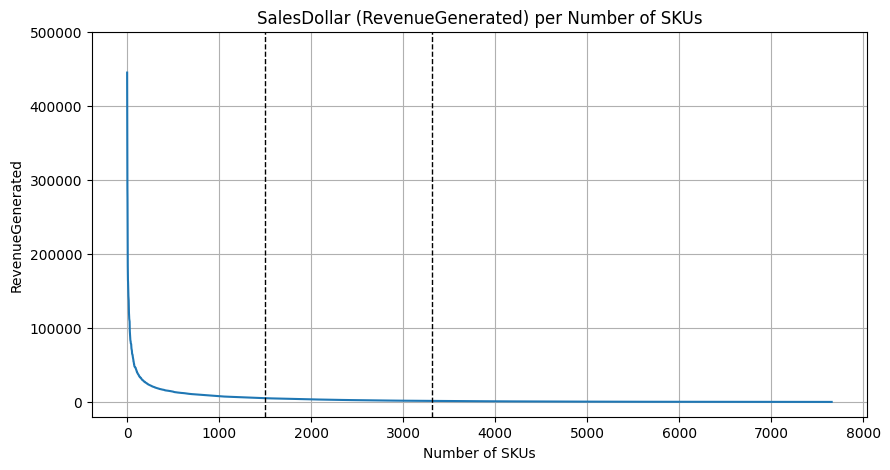

In [214]:
#Distribution of SalesDollars by Quantity of SKU
fig, ax = plt.subplots(figsize = (10,5))
y_axis = pd.Series(range(1, len(data_seg['RevenueGenerated']) + 1))

lineA = data_seg[data_seg.Class == 'A']['Class'].count()
lineB = (data_seg[data_seg.Class == 'A']['Class'].count()) + (data_seg[data_seg.Class == 'B']['Class'].count())

plt.plot(y_axis, data_seg['RevenueGenerated'])
plt.ylabel('RevenueGenerated')
plt.xlabel('Number of SKUs')
plt.title('SalesDollar (RevenueGenerated) per Number of SKUs')

plt.axvline(lineA , color="black", linestyle="--", linewidth = 1.0)
plt.axvline(lineB , color="black", linestyle="--", linewidth = 1.0)

plt.grid(True)
plt.ylim((-20000,500000))
plt.show()

Text(0.5, 1.0, 'Number of Brands by Class')

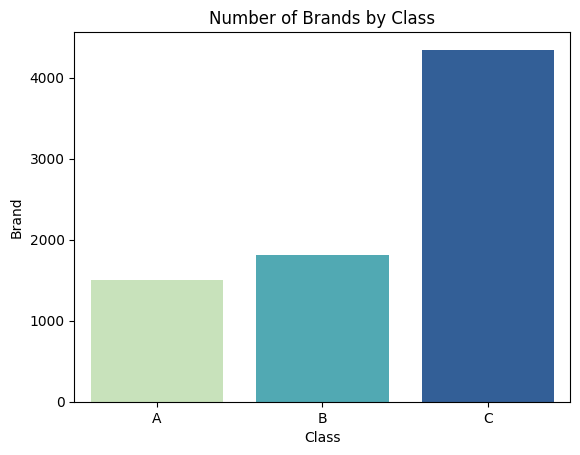

In [215]:
#Number of Brands by Class
ABC = data_seg[['Brand', 'Description', 'Class']].groupby('Class', as_index= False).count()
sns.barplot(x='Class', y = 'Brand', data=ABC,
            hue='Class',
            palette= "YlGnBu",
            legend=False)
plt.title('Number of Brands by Class')

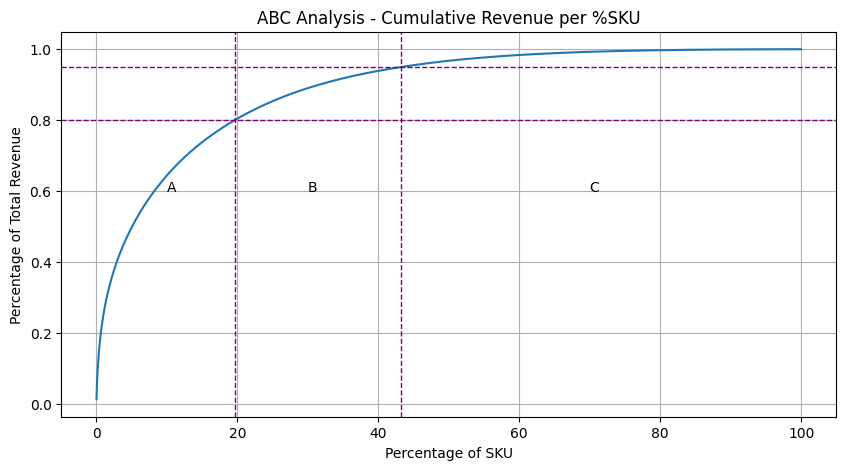

In [216]:
#Distribution of % Total Revenue by % SKU
fig, ax = plt.subplots(figsize = (10,5))
lineA = 100*data_seg[data_seg.Class == 'A']['Class'].count()/data_seg['RevenueGenerated'].count()
lineB = 100*((data_seg[data_seg.Class == 'A']['Class'].count()/data_seg['RevenueGenerated'].count()) + (data_seg[data_seg.Class == 'B']['Class'].count()/data_seg['RevenueGenerated'].count()))

plt.plot(data_seg['SKU_%'], data_seg['PerCumTot'])
plt.xlabel('Percentage of SKU')
plt.ylabel('Percentage of Total Revenue')
plt.title('ABC Analysis - Cumulative Revenue per %SKU')

plt.axvline(lineA , color="purple", linestyle="--", linewidth = 1.0)
plt.axvline(lineB , color="purple", linestyle="--", linewidth = 1.0)

plt.axhline(0.8 , color="purple", linestyle="--", linewidth = 1.0)
plt.axhline(0.95 , color="purple", linestyle="--", linewidth = 1.0)

plt.text(10, 0.6, 'A')  
plt.text(30, 0.6, 'B')  
plt.text(70, 0.6, 'C ')  

plt.grid(True)
plt.show()

<a id="section-seven-two"></a>
### 7.2. XYZ classification

*An* **XYZ analysis** *divides items into three categories. X items have the lowest demand variability. Y items have a moderate amount of demand variability, usually because of a known factor. Z items have the highest demand variability and are therefore the hardest to forecast.*

![My Image](https://shopup.me/-cms/wp-content/uploads/2016/08/XYZ-600x338.png)

In [217]:
#Long to wide data frame
XYZ_df = turn_df1.pivot(index=['Brand', 'Description'], columns='TransactionDate', values='SalesQuantity')
XYZ_df.head()

,TransactionDate,2016-01-01,2016-01-02,2016-01-03,2016-01-04,2016-01-05,2016-01-06,2016-01-07,2016-01-08,2016-01-09,2016-01-10,...,2016-02-20,2016-02-21,2016-02-22,2016-02-23,2016-02-24,2016-02-25,2016-02-26,2016-02-27,2016-02-28,2016-02-29
Brand,Description,,,,,,,,,,,,,,,,,,,,,
58,Gekkeikan Black & Gold Sake,7.0,13.0,7.0,3.0,5.0,4.0,6.0,10.0,9.0,6.0,...,4.0,NaN,1.0,2.0,NaN,NaN,2.0,2.0,2.0,NaN
60,Canadian Club 1858 VAP,3.0,9.0,5.0,3.0,1.0,3.0,3.0,7.0,5.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61,Margaritaville Silver,NaN,NaN,NaN,NaN,NaN,NaN,12.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62,Herradura Silver Tequila,3.0,6.0,6.0,NaN,NaN,5.0,4.0,11.0,9.0,NaN,...,4.0,3.0,2.0,1.0,NaN,4.0,NaN,NaN,2.0,NaN
63,Herradura Reposado Tequila,8.0,8.0,1.0,NaN,1.0,2.0,4.0,10.0,2.0,NaN,...,3.0,1.0,NaN,1.0,NaN,NaN,3.0,1.0,NaN,NaN


In [218]:
#A day with a null value is a day where no item was sold:
XYZ_df.replace(np.nan, 0, inplace=True)
XYZ_df.head()

,TransactionDate,2016-01-01,2016-01-02,2016-01-03,2016-01-04,2016-01-05,2016-01-06,2016-01-07,2016-01-08,2016-01-09,2016-01-10,...,2016-02-20,2016-02-21,2016-02-22,2016-02-23,2016-02-24,2016-02-25,2016-02-26,2016-02-27,2016-02-28,2016-02-29
Brand,Description,,,,,,,,,,,,,,,,,,,,,
58,Gekkeikan Black & Gold Sake,7.0,13.0,7.0,3.0,5.0,4.0,6.0,10.0,9.0,6.0,...,4.0,0.0,1.0,2.0,0.0,0.0,2.0,2.0,2.0,0.0
60,Canadian Club 1858 VAP,3.0,9.0,5.0,3.0,1.0,3.0,3.0,7.0,5.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
61,Margaritaville Silver,0.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
62,Herradura Silver Tequila,3.0,6.0,6.0,0.0,0.0,5.0,4.0,11.0,9.0,0.0,...,4.0,3.0,2.0,1.0,0.0,4.0,0.0,0.0,2.0,0.0
63,Herradura Reposado Tequila,8.0,8.0,1.0,0.0,1.0,2.0,4.0,10.0,2.0,0.0,...,3.0,1.0,0.0,1.0,0.0,0.0,3.0,1.0,0.0,0.0


In [219]:
#Create function
def XYZ_segmentation(cv):
    if cv < 0.5:
        return 'X'
    elif cv >= 0.5 and cv <= 1:
        return 'Y'
    elif cv > 1:
        return 'Z'

In [220]:
def XYZ_classifier(df, average_daily_demand):  
    #Calculate Average Demand of each brand
    df[average_daily_demand] = df.iloc[: , 0:df.shape[1]].mean(axis=1)

    #Calculate STD Demand of each brand
    df['StdDemand'] = df.iloc[: , 0:df.shape[1]-1].std(axis=1)

    #Calculate CV of each brand
    df['CV'] = df['StdDemand']/df[average_daily_demand]

    #Order by CV
    df.sort_values(by=['CV'], ascending= True, inplace= True)

    #Create Class column by Apply function
    df['Class'] = df['CV'].apply(XYZ_segmentation)

    #Reset index of data frame
    df.reset_index(inplace=True)

    return df

In [221]:
XYZ_df = XYZ_classifier(XYZ_df, 'AverageDailyDemand')
XYZ_df.head()

TransactionDate,Brand,Description,2016-01-01 00:00:00,2016-01-02 00:00:00,2016-01-03 00:00:00,2016-01-04 00:00:00,2016-01-05 00:00:00,2016-01-06 00:00:00,2016-01-07 00:00:00,2016-01-08 00:00:00,...,2016-02-24 00:00:00,2016-02-25 00:00:00,2016-02-26 00:00:00,2016-02-27 00:00:00,2016-02-28 00:00:00,2016-02-29 00:00:00,AverageDailyDemand,StdDemand,CV,Class
0,3687,Fleischmanns Royal Traveler,44.0,74.0,65.0,34.0,35.0,42.0,31.0,71.0,...,15.0,5.0,18.0,26.0,13.0,12.0,28.666667,15.942340,0.556128,Y
1,12213,Evodia Garnacha Old Vine,10.0,39.0,19.0,14.0,7.0,35.0,14.0,27.0,...,16.0,18.0,40.0,22.0,33.0,1.0,22.516667,13.420818,0.596039,Y
2,12220,Angeline Pnt Nr,18.0,31.0,23.0,16.0,23.0,43.0,29.0,39.0,...,17.0,33.0,60.0,37.0,10.0,4.0,34.250000,21.530920,0.628640,Y
3,26463,Ravenswood Vints Blend Znfdl,32.0,60.0,16.0,5.0,9.0,11.0,9.0,16.0,...,9.0,32.0,43.0,30.0,8.0,11.0,20.166667,13.267990,0.657917,Y
4,4359,Mr Boston Light Rum,26.0,57.0,26.0,12.0,7.0,22.0,21.0,29.0,...,18.0,21.0,5.0,14.0,14.0,1.0,19.183333,12.829378,0.668777,Y


In [222]:
# Min,Max CV?
print('Minimum Coefficient of Variation:', XYZ_df['CV'].min().round(2))
print('Maximum Coefficient of Variation:', XYZ_df['CV'].max().round(2))

Minimum Coefficient of Variation: 0.56
Maximum Coefficient of Variation: 7.75


Text(0.5, 1.0, 'Number of Brands by Class')

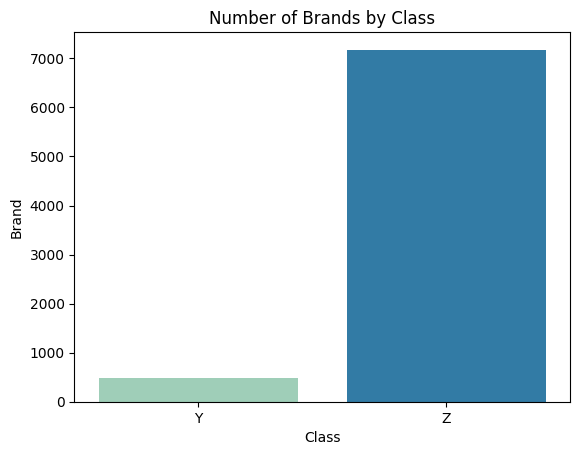

In [223]:
#Number of Brands by Class
XYZ = XYZ_df[['Brand', 'Description', 'Class']].groupby('Class', as_index= False).count()
sns.barplot(x='Class', y = 'Brand', data=XYZ,
            hue='Class',
            palette= "YlGnBu",
            legend=False)
plt.title('Number of Brands by Class')

<a id="section-seven-three"></a>
### 7.3. Integration of ABC and XYZ analysis

*The main idea of the ABC XYZ analysis is to combine ABC and XYZ categories across two dimensions: we end up with a matrix of 9 categories.*

![My Image](https://miro.medium.com/v2/resize:fit:1190/1*UE0HHiBs-ViRM4-4-Bv3qA.png)


In [224]:
#Merge two data frames 
ABC_XYZ_df = pd.merge(data_seg[['Brand', 'Description', 'Class', 'RevenueGenerated']], XYZ_df[['Brand', 'Description', 'Class', 'CV']], 
                      how= 'inner', 
                      on= ['Brand', 'Description'])
ABC_XYZ_df.head()

,Brand,Description,Class_x,RevenueGenerated,Class_y,CV
0,4261,Capt Morgan Spiced Rum,A,444810.74,Z,1.021512
1,3545,Ketel One Vodka,A,357759.17,Z,1.146796
2,1233,Jack Daniels No 7 Black,A,344712.22,Y,0.956637
3,8068,Absolut 80 Proof,A,288135.11,Y,0.930204
4,3405,Tito's Handmade Vodka,A,275162.97,Z,1.113261


In [225]:
#Create Combine column
ABC_XYZ_df['Combine'] = (ABC_XYZ_df['Class_x']+ABC_XYZ_df['Class_y']).astype(str)
#ABC_XYZ_df.drop(columns = {'Class_x', 'Class_y'}, inplace= True)
ABC_XYZ_df.head()

,Brand,Description,Class_x,RevenueGenerated,Class_y,CV,Combine
0,4261,Capt Morgan Spiced Rum,A,444810.74,Z,1.021512,AZ
1,3545,Ketel One Vodka,A,357759.17,Z,1.146796,AZ
2,1233,Jack Daniels No 7 Black,A,344712.22,Y,0.956637,AY
3,8068,Absolut 80 Proof,A,288135.11,Y,0.930204,AY
4,3405,Tito's Handmade Vodka,A,275162.97,Z,1.113261,AZ


In [226]:
#Number of Brands of each category:
categories = ['AX', 'AY', 'AZ', 'BX', 'BY', 'BZ', 'CX', 'CY', 'CZ']
for category in categories:
    count = ABC_XYZ_df[ABC_XYZ_df.Combine == category]['Combine'].count()
    percentage = (count / ABC_XYZ_df.shape[0] * 100).round(2)
    print(f'Number of {category} brands: {count}, {percentage}%')

Number of AX brands: 0, 0.0%
Number of AY brands: 376, 4.91%
Number of AZ brands: 1126, 14.7%
Number of BX brands: 0, 0.0%
Number of BY brands: 104, 1.36%
Number of BZ brands: 1709, 22.32%
Number of CX brands: 0, 0.0%
Number of CY brands: 1, 0.01%
Number of CZ brands: 4342, 56.7%


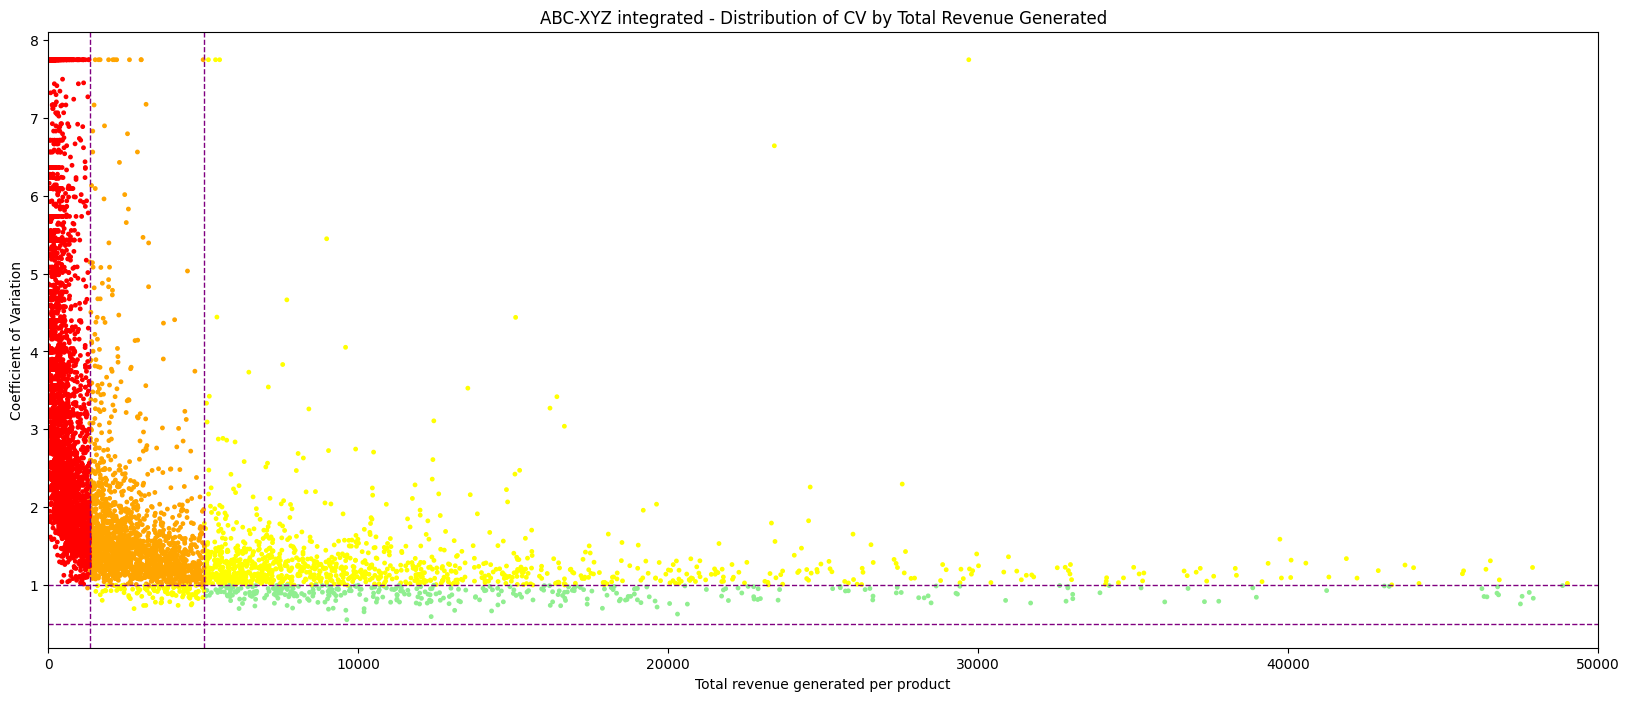

In [227]:
#Distribution of CV by %Rev
limit_C = ABC_XYZ_df[ABC_XYZ_df.Class_x == 'C']['RevenueGenerated'].max()
limit_B = ABC_XYZ_df[ABC_XYZ_df.Class_x == 'B']['RevenueGenerated'].max()

plt.figure(figsize=(20,8))
colors = {'AX':'green', 'AY':'lightgreen', 'AZ':'yellow',
          'BX':'lightgreen', 'BY':'yellow', 'BZ':'orange',
          'CX':'yellow', 'CY':'orange', 'CZ':'red'}

plt.scatter(ABC_XYZ_df['RevenueGenerated'], ABC_XYZ_df['CV'], color=ABC_XYZ_df['Combine'].map(colors), s= 6)
plt.xlabel('Total revenue generated per product')
plt.ylabel('Coefficient of Variation')
plt.title('ABC-XYZ integrated - Distribution of CV by Total Revenue Generated')

plt.axvline(limit_C , color="purple", linestyle="--", linewidth = 1.0)
plt.axvline(limit_B , color="purple", linestyle="--", linewidth = 1.0)

plt.axhline(0.5 , color="purple", linestyle="--", linewidth = 1.0)
plt.axhline(1 , color="purple", linestyle="--", linewidth = 1.0)

plt.xlim((0,50000))

plt.show()

<a id="section-eight"></a>
## 8. Safety Stock and Re-order Point

**- Cycle Service Level (CSL):** *probability of not stock out in a cycle*

**- Safety Stock** *= Z x SQRT(Average Leadtime x (STD of Demand)^2  + (Average Daily Demand x STD of Leadtime)^2)* 

*(assume the relation between demand and lead time is independent and both are normally distributed)*

**- Re-order Point** *= Average Daily Demand x Leadtime + Safety Stock*

*Reference: https://abcsupplychain.com/safety-stock-formula-calculation/#Safety_Stock_Method_5_Normal_distribution_with_uncertainty_about_the_demand_and_the_lead_time_independent*

<a id="section-eight-one"></a>
### 8.1. Safety Stock with CSL (demand & lead time uncertainty)

**Matching demand with supply through the service level of each ABC-XYZ category:**

In [228]:
#Define Service level targets per category
service_level = {'AX': 0.98, 'AY': 0.96, 'AZ': 0.94,
                 'BX': 0.96, 'BY': 0.94, 'BZ': 0.92,
                 'CX': 0.94, 'CY':0.92, 'CZ':0.9}

**Assumptions:** *Continuous Review Policy (s, Q) = inventory level will be checked every day, if inventory level ≤ s will order Q*

In [229]:
ss_df1 = XYZ_df[['Brand', 'Description', 'AverageDailyDemand', 'StdDemand']].copy()

ss_df2 = pd.merge(brand_lt[['Brand', 'Description', 'Avg_LT', 'Std_LT']], ss_df1[['Brand', 'Description', 'AverageDailyDemand','StdDemand']], 
                  how= 'right', 
                  on= ['Brand', 'Description'])

ss_df3 = pd.merge(ss_df2, ABC_XYZ_df[['Brand', 'Description', 'Combine']], how= 'inner', on= ['Brand', 'Description'])

ss_df3['ServiceLevel'] = ss_df3['Combine'].map(service_level)

ss_df3['k'] = stats.norm(0, 1).ppf(ss_df3['ServiceLevel'])

ss_df3['SafetyStock'] = ss_df3['k']*np.sqrt((ss_df3['StdDemand']**2)*(ss_df3['Avg_LT']) + ((ss_df3['AverageDailyDemand']*ss_df3['Std_LT'])**2))

ss_df3.head()

,Brand,Description,Avg_LT,Std_LT,AverageDailyDemand,StdDemand,Combine,ServiceLevel,k,SafetyStock
0,3687,Fleischmanns Royal Traveler,7.65,2.22,28.666667,15.942340,AY,0.96,1.750686,135.543807
1,12213,Evodia Garnacha Old Vine,7.90,2.04,22.516667,13.420818,AY,0.96,1.750686,104.057155
2,12220,Angeline Pnt Nr,7.96,2.11,34.250000,21.530920,AY,0.96,1.750686,165.277120
3,26463,Ravenswood Vints Blend Znfdl,7.71,2.10,20.166667,13.267990,AY,0.96,1.750686,98.269292
4,4359,Mr Boston Light Rum,7.52,2.22,19.183333,12.829378,AY,0.96,1.750686,96.706851


In [230]:
#Top 10 brands with the highest SafetyStock:
top10_ss = ss_df3[['Brand', 'Description', 'Combine', 'SafetyStock']].sort_values(by='SafetyStock', ascending= False)
print('Top 10 brands with the highest SafetyStock: \n', top10_ss.head(10))

Top 10 brands with the highest SafetyStock: 
       Brand                   Description Combine  SafetyStock
106    8111             Smirnoff 80 Proof      AY  2645.573469
82     1892                    Yukon Jack      AY  2109.362492
546    4261        Capt Morgan Spiced Rum      AZ  1856.229753
311    5111  Dr McGillicuddy's Mentholmnt      AY  1801.527058
79     3606      Smirnoff Raspberry Vodka      AY  1744.329418
78     3837                    Skyy Vodka      AY  1263.736152
1102   3545               Ketel One Vodka      AZ  1173.321137
60     4135      Smirnoff Blueberry Vodka      AY  1114.529108
280    8068              Absolut 80 Proof      AY  1092.127269
28     4157    Smirnoff Green Apple Vodka      AY  1086.106604


<a id="section-eight-two"></a>
### 8.2. Re-order Point (ROP)

In [231]:
ss_df3['ReorderPoint'] = (ss_df3['Avg_LT']*ss_df3['AverageDailyDemand'] + ss_df3['SafetyStock']).round(2)

ss_df3.sort_values(by='Brand', ascending= True, inplace= True)

ss_df3.head()

,Brand,Description,Avg_LT,Std_LT,AverageDailyDemand,StdDemand,Combine,ServiceLevel,k,SafetyStock,ReorderPoint
348,58,Gekkeikan Black & Gold Sake,7.76,2.07,4.800000,4.587381,BY,0.94,1.554774,25.167461,62.42
1847,60,Canadian Club 1858 VAP,7.66,2.66,2.066667,2.711349,BZ,0.92,1.405072,13.070375,28.90
6254,61,Margaritaville Silver,8.12,2.08,0.400000,2.172244,CZ,0.90,1.281552,8.004068,11.25
544,62,Herradura Silver Tequila,7.33,2.24,2.700000,2.757424,AZ,0.94,1.554774,14.938061,34.73
1326,63,Herradura Reposado Tequila,7.32,2.10,2.183333,2.619947,AZ,0.94,1.554774,13.125422,29.11


<a id="section-nine"></a>
## 9. Fixed-Order Quantity Models (EOQ model)  

**Assumptions:**

*- Annual holding cost rate per unit per year equal to 12%*

*- The Order Placement Cost is the freight cost in inv_pur dataframe*

In [232]:
h = 0.12

In [233]:
EOQ_df0 = COGS_df[['Brand', 'Description', 'SalesQuantity','SalesPrice', 'PurchasePrice']].groupby(['Brand', 'Description'], as_index= False).agg({'SalesQuantity': 'sum',
                                                                                                                                         'SalesPrice': 'first',
                                                                                                                                         'PurchasePrice': 'first'})

EOQ_df1 = pd.merge(EOQ_df0[['Brand', 'Description', 'SalesQuantity','SalesPrice', 'PurchasePrice']], sales_final[['Brand', 'Description', 'VendorNo', 'VendorName' ]], 
                   how= 'left', 
                   on= ['Brand', 'Description'])
EOQ_df1.rename(columns= {'VendorNo': 'VendorNumber'}, inplace= True)

order_placement_cost = inv_pur[['VendorNumber', 'VendorName', 'Freight' ]].groupby(['VendorNumber', 'VendorName'], as_index= False)['Freight'].mean().round(2)

EOQ_df3 = pd.merge(EOQ_df1, order_placement_cost, 
                   how= 'left', 
                   on= ['VendorNumber', 'VendorName'])
EOQ_df3.fillna(EOQ_df3['Freight'].mean(), inplace= True)
EOQ_df3 = EOQ_df3.groupby(['Brand', 'Description', 'SalesQuantity','SalesPrice', 'PurchasePrice'], as_index= False)['Freight'].mean()
EOQ_df3.rename(columns= {'Freight': 'OrderPlacementCost'}, inplace= True)
EOQ_df3['UnitHoldingCost'] = (h/6)*EOQ_df3['PurchasePrice']

EOQ_df3.head()

,Brand,Description,SalesQuantity,SalesPrice,PurchasePrice,OrderPlacementCost,UnitHoldingCost
0,58,Gekkeikan Black & Gold Sake,288,12.99,9.28,2377.271117,0.1856
1,60,Canadian Club 1858 VAP,124,9.99,7.40,2305.330000,0.1480
2,61,Margaritaville Silver,24,13.99,10.60,1390.010000,0.2120
3,62,Herradura Silver Tequila,162,36.99,28.67,1554.190000,0.5734
4,63,Herradura Reposado Tequila,131,38.99,30.46,1554.190000,0.6092


In [234]:
EOQ_df4 = pd.merge(EOQ_df3, ss_df3[['Brand', 'Description', 'SafetyStock', 'ReorderPoint']],
                   how= 'right', 
                   on= ['Brand', 'Description'])
EOQ_df4.dropna(axis=0,inplace= True)

EOQ_df4.head()

,Brand,Description,SalesQuantity,SalesPrice,PurchasePrice,OrderPlacementCost,UnitHoldingCost,SafetyStock,ReorderPoint
0,58,Gekkeikan Black & Gold Sake,288,12.99,9.28,2377.271117,0.1856,25.167461,62.42
1,60,Canadian Club 1858 VAP,124,9.99,7.40,2305.330000,0.1480,13.070375,28.90
2,61,Margaritaville Silver,24,13.99,10.60,1390.010000,0.2120,8.004068,11.25
3,62,Herradura Silver Tequila,162,36.99,28.67,1554.190000,0.5734,14.938061,34.73
4,63,Herradura Reposado Tequila,131,38.99,30.46,1554.190000,0.6092,13.125422,29.11


In [235]:
#EOQ
EOQ_df4['EOQ'] = np.sqrt((2*EOQ_df3['SalesQuantity']*EOQ_df4['OrderPlacementCost'])/EOQ_df4['UnitHoldingCost'] ).round(2)
#Maximum Inventory Level
EOQ_df4['Max.InventoryLevel'] = EOQ_df4['EOQ'] + EOQ_df4['SafetyStock'] 

EOQ_df4.head()

,Brand,Description,SalesQuantity,SalesPrice,PurchasePrice,OrderPlacementCost,UnitHoldingCost,SafetyStock,ReorderPoint,EOQ,Max.InventoryLevel
0,58,Gekkeikan Black & Gold Sake,288,12.99,9.28,2377.271117,0.1856,25.167461,62.42,2716.20,2741.367461
1,60,Canadian Club 1858 VAP,124,9.99,7.40,2305.330000,0.1480,13.070375,28.90,1965.45,1978.520375
2,61,Margaritaville Silver,24,13.99,10.60,1390.010000,0.2120,8.004068,11.25,561.00,569.004068
3,62,Herradura Silver Tequila,162,36.99,28.67,1554.190000,0.5734,14.938061,34.73,937.12,952.058061
4,63,Herradura Reposado Tequila,131,38.99,30.46,1554.190000,0.6092,13.125422,29.11,817.57,830.695422


<a id="section-ten"></a>
## 10. Vendors Evaluation

<a id="section-ten-one"></a>
### 10.1. Vendor's Lead Time

In [236]:
#Min, max, std, average leadtime of Vendors
vendor_lt = pur_final.groupby(['VendorName', 'VendorNumber'], as_index=False).agg(Min_LT = ('Leadtime', 'min'),
                                                                                  Max_LT = ('Leadtime', 'max'),
                                                                                  Avg_LT = ('Leadtime', 'mean'),
                                                                                  Std_LT = ('Leadtime', 'std'),
                                                                                  NumberOfOrders = ('PONumber', 'nunique')).round(2).sort_values(by = ['Avg_LT'], ascending =True).reset_index(drop=True)
vendor_lt.head()

,VendorName,VendorNumber,Min_LT,Max_LT,Avg_LT,Std_LT,NumberOfOrders
0,TRUETT HURST,9099,5,5,5.00,NaN,1
1,HIGHLAND WINE MERCHANTS LLC,3951,3,9,5.32,2.18,7
2,LOYAL DOG WINERY,5083,4,12,5.95,2.44,3
3,MARTIGNETTI COMPANIES,4425,3,12,6.70,1.97,27
4,ALISA CARR BEVERAGES,1703,3,12,6.81,2.72,19


c:\Users\Zenbook\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:1832: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=self.x, y=self.y, **kwargs)


Text(37.722222222222214, 0.5, 'Number of Orders')

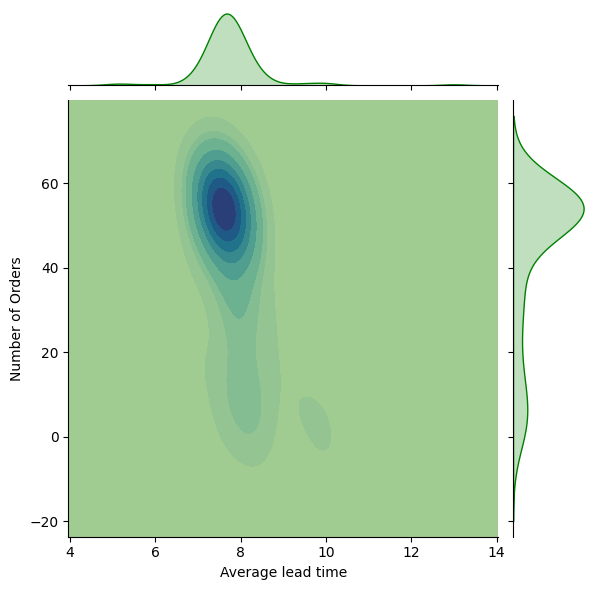

In [237]:
#Distribution between Number of Orders and Average Lead time
sns.jointplot(x= 'Avg_LT', y = 'NumberOfOrders', data=vendor_lt,
              kind= "kde",
              fill=True,
              color='green', 
              thresh=0,  
              shade= True,
              cmap= 'crest')  
plt.xlabel('Average lead time')
plt.ylabel('Number of Orders')

In [238]:
#Top 10 vendors with the shortest leadtime:
top10 = vendor_lt[['VendorNumber', 'VendorName',  'Avg_LT']].sort_values(by='Avg_LT', ascending= True)
print('Top 10 vendors with the shortest leadtime: \n', top10.head(10))

Top 10 vendors with the shortest leadtime: 
    VendorNumber                       VendorName  Avg_LT
0          9099      TRUETT HURST                   5.00
1          3951      HIGHLAND WINE MERCHANTS LLC    5.32
2          5083      LOYAL DOG WINERY               5.95
3          4425           MARTIGNETTI COMPANIES     6.70
4          1703  ALISA CARR BEVERAGES               6.81
5          1650      Circa Wines                    6.95
6          9206      PHILLIPS PRODUCTS CO.          7.01
7          8150      SEA HAGG DISTILLERY LLC        7.02
8          6355      NICHE W & S                    7.07
9          6215      MOONLIGHT MEADERY              7.08


In [239]:
#Top 10 vendors with the largest number of orders:
top10 = vendor_lt[['VendorNumber', 'VendorName',  'NumberOfOrders']].sort_values(by='NumberOfOrders', ascending= False)
print('Top 10 vendors with the largest number of orders: \n', top10.head(10))

Top 10 vendors with the largest number of orders: 
     VendorNumber                   VendorName  NumberOfOrders
63         90047  CRUSH WINES                              55
66          2242  DELICATO VINEYARDS INC                   55
34          6785  PALM BAY INTERNATIONAL INC               55
35          1485  CASTLE BRANDS CORP.                      55
36          1587  VINEYARD BRANDS INC                      55
80          8320  SHAW ROSS INT L IMP LTD                  55
38           660  SAZERAC NORTH AMERICA INC.               55
39         12546  JIM BEAM BRANDS COMPANY                  55
40          8004  SAZERAC CO INC                           55
41          2000  SOUTHERN WINE & SPIRITS NE               55


<a id="section-ten-two"></a>
### 10.2. Total Gross Profit per Vendor

In [240]:
profit_per_vendor = ((pd.merge(COGS_df[['Brand', 'Description', 'Profit']], sales_final[['Brand', 'Description', 'VendorNo', 'VendorName']],
                             on= ['Brand', 'Description'],
                             how= 'left')
                     ).drop(columns={'Brand', 'Description'})
                     ).rename(columns={'VendorNo':'VendorNumber'}).groupby(['VendorNumber', 'VendorName'], as_index= False).sum()

profit_per_vendor.head()

,VendorNumber,VendorName,Profit
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",2.626000e+01
1,105,ALTAMAR BRANDS LLC,3.059640e+03
2,287,APPOLO VINEYARDS LLC,1.713100e+02
3,388,ATLANTIC IMPORTING COMPANY,1.526499e+05
4,480,BACARDI USA INC,4.725701e+08


In [241]:
#Top 10 vendors with the highest gross profit:
top10 = profit_per_vendor.sort_values(by='Profit', ascending= False)
print('Top 10 vendors with the highest gross profit: \n', top10.head(10))

Top 10 vendors with the highest gross profit: 
     VendorNumber                   VendorName        Profit
36          3960  DIAGEO NORTH AMERICA INC     1.452469e+09
93         17035  PERNOD RICARD USA            6.259871e+08
38          4425        MARTIGNETTI COMPANIES  6.020857e+08
89         12546  JIM BEAM BRANDS COMPANY      5.986128e+08
14          1392  CONSTELLATION BRANDS INC     5.113007e+08
4            480  BACARDI USA INC              4.725701e+08
10          1128  BROWN-FORMAN CORP            3.957770e+08
32          3252  E & J GALLO WINERY           3.395771e+08
62          8004  SAZERAC CO INC               2.473064e+08
82          9815  WINE GROUP INC               2.023761e+08


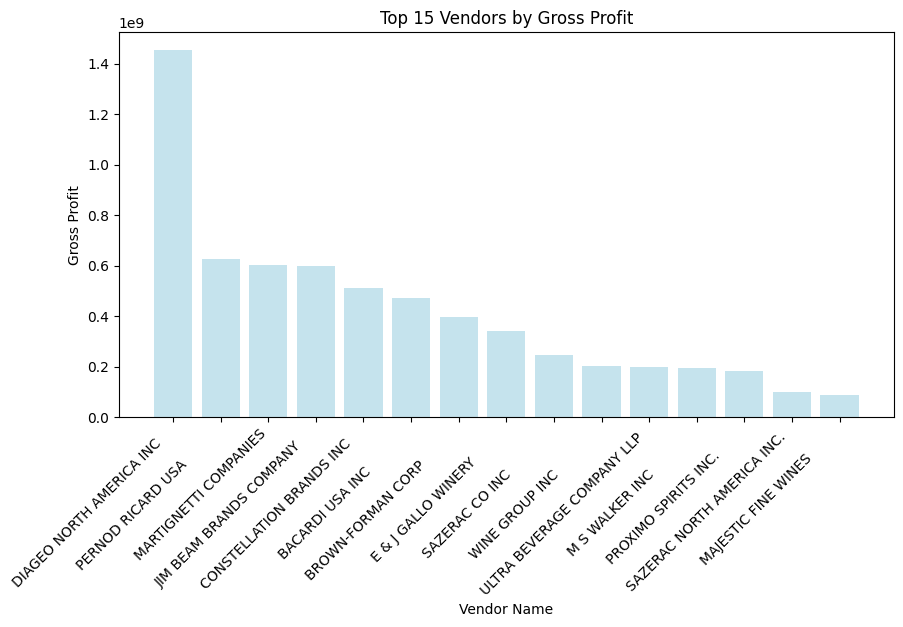

In [242]:
#Top 15 Vendors by Profit Visualization
plt.figure(figsize=(10, 5))
plt.bar(top10['VendorName'].head(15), top10['Profit'].head(15), color='lightblue', alpha= 0.7 )
plt.title('Top 15 Vendors by Gross Profit')
plt.ylabel('Gross Profit')
plt.xlabel('Vendor Name')
plt.xticks(rotation=45, ha='right')
plt.show()